# Credit Card Portfolio Risk Review

**Prepared by:** Kailai Yang  
**Project type:** Independent historical data analysis  
**Data period:** April–September 2005, with a next-month outcome label  
**Last updated:** 2026-09-12

## Executive Summary

This analysis reviews 30,000 historical Taiwanese credit card
clients to identify segments for further investigation.
The overall next-month default-label rate is 22.12%.

**Key findings**
- Clients with PAY_0 >= 2 represent 10.43% of the sample but
  account for 32.81% of positive labels. Their label rate is
  69.55%, indicating substantial concentration, but limited
  overall coverage.
- Within PAY_0 >= 2, label rates remain approximately 69–71%
  across credit-limit bands. Higher limits do not identify
  an obviously lower-rate subgroup.
- Expanding review to PAY_0 > 0 increases coverage to 51.67%
  and selects 22.73% of clients. This adds 3,688 clients to
  review and 1,252 positive labels, more than doubling
  review volume.

**Recommended decision**
Define the intended follow-up action and available review
capacity, then validate both candidate scopes on recent
independent data before operational use.

**Key limitation**
These findings describe a 2005 historical sample, not current
Canadian risk. They do not establish causation, intervention
effectiveness or losses prevented. Source coding and outcome
definitions require clarification.

## 1. Business Objective and Scope

### Business question

Which repayment behaviours and customer segments are associated
with a higher next-month default-label rate in this sample?

### Intended decision

Support the prioritisation of customer segments for further
investigation, considering both observed risk concentration
and the number of customers involved.

### Initial analytical questions

1. What is the overall next-month default-label rate?
2. How does that rate differ by recent repayment status?
3. How does default risk vary across credit-limit segments within each repayment status?
4. How many customers and positive labels are captured by
   each segment?

### In scope

- Data quality assessment.
- Descriptive portfolio analysis.
- Repayment-behaviour segmentation.
- Investigation of selected segment differences.
- Evidence-based recommendations and limitations.

### Out of scope

- Estimating current Canadian credit risk.
- Making individual approval, rejection, or credit-limit decisions.
- Claiming that observed associations are causal.
- Building a production credit-scoring model.

## 2. Data Source and Loading

### Source

- **Dataset:** Default of Credit Card Clients
- **Kaggle:** https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
- **Original source:** UCI Machine Learning Repository
- **DOI:** https://doi.org/10.24432/C55S3H
- **Access date:** 2026-09-08

### Source-described structure

The source describes 30,000 clients, 23 explanatory variables,
a client identifier, and a binary default-payment outcome.

The explanatory variables include credit limit, customer
attributes, and six months of repayment status, bill amounts,
and payment amounts.

### Verification approach

The actual file structure, column names, record count, and
data types will be checked before any cleaning or analysis.

The downloaded file will be treated as the source input.
Any subsequent transformations will be documented.

### 2.1 Load the Local Dataset

Load `data/UCI_Credit_Card.csv` from the project directory. The loader works
from the repository root or a directory inside it, including this notebook's folder.
The bundled CSV was converted from UCI's original XLS with the target column
renamed to match this notebook; numeric values and client rows are preserved.
See `data/README.md` for provenance and license details.


In [1]:
from pathlib import Path
import sys

import pandas as pd

# Find the repository root and its data file from the current folder or its parents.
current_dir = Path.cwd().resolve()
REPO_ROOT = next(
    (folder for folder in (current_dir, *current_dir.parents)
     if (folder / "SPECS.md").is_file()
     and (folder / "data" / "UCI_Credit_Card.csv").is_file()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Cannot find data/UCI_Credit_Card.csv. Download the complete repository "
        "and start Jupyter from its root or a subdirectory."
    )

# Make the shared core/ package importable regardless of the notebook's working directory.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_PATH = REPO_ROOT / "data" / "UCI_Credit_Card.csv"
df = pd.read_csv(DATA_PATH)
print("Loaded data/UCI_Credit_Card.csv")
df.head()

Loaded data/UCI_Credit_Card.csv


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Validate the Loaded Data

Run the shared data-quality checks (`core/validator.py`) immediately
after loading the data, before calculating any portfolio metric.
These checks confirm required columns, client-ID integrity, numeric
analysis fields, missing values, and a binary outcome label; analysis
stops here if a required check fails. Repayment-status codes that are
not explained in the source description are reported as warnings,
without inventing a meaning for them.

In [2]:
from core.validator import validate_portfolio

# Run the shared data-quality checks immediately after loading, before
# calculating any portfolio metric. Analysis stops here if a required
# check fails.
validation_result = validate_portfolio(df)
assert validation_result.is_valid, validation_result.errors

print(
    f"Validation passed: {len(validation_result.errors)} error(s), "
    f"{len(validation_result.warnings)} warning(s)."
)
for warning in validation_result.warnings:
    print("-", warning)

Validation passed: 0 error(s), 1 warning(s).
- Column 'PAY_0' contains code(s) not documented in the source description reviewed: -2, 0. Retained without assigning an interpretation.


### 2.2 Understand the Data Structure

Check the dataset dimensions and column names to understand
the available information before assessing data quality.

In [3]:
# Check the number of records and fields.
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# List every column, including those hidden in the preview.
print(df.columns.tolist())

Rows: 30000
Columns: 25
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


The dataset contains 30,000 rows and 25 columns, consistent
with the source description.

Each row is intended to represent one client; ID uniqueness
will be verified in the data quality checks.

The columns include a client identifier, credit limit,
customer attributes, six months of repayment information,
and a next-month default-payment label.

In [4]:
# Count each outcome value, including missing values.
target_col = "default.payment.next.month"

df[target_col].value_counts(dropna=False)

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

### 2.3 Establish the Portfolio Baseline

Calculate the overall next-month default-label rate.
This provides a baseline for comparing customer segments.

In [5]:
from core.metrics import portfolio_overview

# Reuse the shared metric definition so the notebook and application agree.
overview = portfolio_overview(df, target_col=target_col)
total_clients = overview["total_clients"]
default_clients = overview["positive_labels"]
default_rate = overview["label_rate"]

print(f"Total clients: {total_clients:,}")
print(f"Clients with label 1: {default_clients:,}")
print(f"Default-label rate: {default_rate:.2%}")

Total clients: 30,000
Clients with label 1: 6,636
Default-label rate: 22.12%


The sample contains 30,000 clients, of whom 6,636 have a
positive next-month default-payment label. The overall
default-label rate is 22.12%.

This is a historical sample rate, not an estimate of current
banking-sector risk.

### 2.4 Check Identifiers, Missing Values and Category Codes

Check that each row has a unique, non-missing client ID
before calculating customer-segment statistics.

In [6]:
# 1. Uniqueness & Missing values
print(f"Unique IDs: {df['ID'].nunique():,} / Total rows: {len(df):,}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values across all columns: {df.isnull().sum().sum()}")

# Required-field checks (columns, ID integrity, numeric types, missing
# values, binary labels) were already confirmed by the shared validator
# immediately after loading the data; see the validation warnings above.

# 2. Check undocumented values in categorical features
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cat_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts(dropna=False).sort_index())

Unique IDs: 30,000 / Total rows: 30,000
Duplicate rows: 0
Missing values across all columns: 0

SEX distribution:
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION distribution:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE distribution:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


All 30,000 records have unique client IDs, with no missing
values or fully duplicated rows.

EDUCATION contains 345 records with codes not covered by
the source description; MARRIAGE contains 54 such records.
These values are retained without assigning unsupported meanings.

### 2.5 Inspect Repayment Status Encodings (PAY_0 to PAY_6)
Verify the observed distribution of repayment status values across the six-month history. 
Identify undocumented values (such as `-2` and `0`) relative to the original data dictionary before constructing behavioral segmentations.

In [7]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Count each observed code, including missing values, for every month.
pay_distribution = pd.DataFrame({
    col: df[col].value_counts(dropna=False)
    for col in pay_cols
}).sort_index()

# A code absent from one month has a frequency of zero.
pay_distribution = pay_distribution.fillna(0).astype(int)

display(pay_distribution)

# Each monthly distribution should account for all 30,000 records.
print(pay_distribution.sum())

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


PAY_0    30000
PAY_2    30000
PAY_3    30000
PAY_4    30000
PAY_5    30000
PAY_6    30000
dtype: int64


### Inspection Findings

- Each monthly status distribution totals 30,000 records,
  matching the dataset size. Earlier checks found no missing
  values in these fields.

- Codes -2 and 0 are present but are not explained in the
  source description reviewed. They are retained without
  assigning additional business meanings.

- Code 1 appears for 3,688 clients in September, compared
  with 28 in August and 0–4 in the earlier months.
  This difference requires clarification before interpreting
  cross-month changes as changes in repayment behaviour.

These tables describe status frequencies, not next-month
default-label rates or individual customer transitions.
The next step is to compare outcome rates by PAY_0 code.

## 3. Analyse Default Labels by Recent Repayment Status

Compare next-month default-label rates across September
repayment-status codes (PAY_0).

Report customer counts alongside rates to identify small
groups and avoid interpreting percentages in isolation.

In [8]:
target_col = "default.payment.next.month"

# Summarise client counts and default-label rates by PAY_0.
pay0_analysis = df.groupby("PAY_0")[target_col].agg(
    total_clients="count",
    default_clients="sum",
    default_rate="mean"
).reset_index()

# Calculate each segment's share of all clients.
pay0_analysis["portfolio_share"] = pay0_analysis["total_clients"] / len(df)

# Format percentages in a separate display table.
pay0_display = pay0_analysis.copy()
pay0_display["default_rate"] = pay0_display["default_rate"].map("{:.2%}".format)
pay0_display["portfolio_share"] = pay0_display["portfolio_share"].map("{:.2%}".format)

display(pay0_display)

,PAY_0,total_clients,default_clients,default_rate,portfolio_share
0,-2,2759,365,13.23%,9.20%
1,-1,5686,954,16.78%,18.95%
2,0,14737,1888,12.81%,49.12%
3,1,3688,1252,33.95%,12.29%
4,2,2667,1844,69.14%,8.89%
5,3,322,244,75.78%,1.07%
6,4,76,52,68.42%,0.25%
7,5,26,13,50.00%,0.09%
8,6,11,6,54.55%,0.04%
9,7,9,7,77.78%,0.03%


### Initial Findings

PAY_0 = 2 has a default-label rate of 69.14%, compared with
22.12% overall. This segment contains 2,667 clients and
1,844 positive labels, making it a candidate for further
investigation.

The highest rate, 77.78% for PAY_0 = 7, is based on only
9 clients and should be interpreted cautiously.

PAY_0 = 0 has a lower rate of 12.81% but contains 1,888
positive labels because of its large customer base.
A high-rate segment alone may therefore provide limited
coverage of all positive labels.

These are descriptive associations. Codes -2 and 0 retain
their original numeric labels because their meanings remain
unresolved in the source description reviewed.

In [9]:
# Measure each segment's share of all positive default labels.
total_defaults = df[target_col].sum()

pay0_analysis["default_share"] = (
    pay0_analysis["default_clients"] / total_defaults
)

# Display counts and coverage without changing numeric values.
default_share_display = pay0_analysis[
    ["PAY_0", "default_clients", "default_share"]
].copy()

default_share_display["default_share"] = (
    default_share_display["default_share"].map("{:.2%}".format)
)

display(default_share_display)

,PAY_0,default_clients,default_share
0,-2,365,5.50%
1,-1,954,14.38%
2,0,1888,28.45%
3,1,1252,18.87%
4,2,1844,27.79%
5,3,244,3.68%
6,4,52,0.78%
7,5,13,0.20%
8,6,6,0.09%
9,7,7,0.11%


### Coverage and Review Workload

PAY_0 = 2 accounts for 8.89% of clients and 27.79% of all
positive default labels.

PAY_0 = 0 accounts for a similar share of positive labels
(28.45%) but a much larger share of clients (49.12%).

This illustrates the trade-off between review workload and
outcome coverage. Historical coverage does not establish
the effectiveness of a follow-up intervention.

### Group Recent Repayment Status

Combine the detailed status codes into three descriptive
segments to summarise risk concentration and review workload.

PAY_0 <= 0 remains a numeric grouping, not a confirmed
“current” or “no-risk” category.

In [10]:
from core.metrics import repayment_status_groups

# Assign a descriptive segment without changing the original PAY_0.
df["pay0_group"] = repayment_status_groups(df)

# Check the number of clients assigned to each group.
df["pay0_group"].value_counts()

pay0_group
PAY_0 <= 0    23182
PAY_0 = 1      3688
PAY_0 >= 2     3130
Name: count, dtype: int64

In [11]:
from core.metrics import segment_summary

# Calculate counts and outcome rates for the three segments.
group_summary = segment_summary(df, df["pay0_group"]).rename(columns={
    "positive_labels": "default_clients",
    "label_rate": "default_rate",
    "label_share": "default_share",
})

# Format a separate table for display.
group_display = group_summary.copy()

for col in ["default_rate", "portfolio_share", "default_share"]:
    group_display[col] = group_display[col].map("{:.2%}".format)

display(group_display)

,total_clients,default_clients,default_rate,portfolio_share,default_share
pay0_group,,,,,
PAY_0 <= 0,23182,3207,13.83%,77.27%,48.33%
PAY_0 = 1,3688,1252,33.95%,12.29%,18.87%
PAY_0 >= 2,3130,2177,69.55%,10.43%,32.81%


### Findings: Risk Concentration and Coverage

The PAY_0 >= 2 segment contains 3,130 clients (10.43% of
the sample) and 2,177 positive labels. Its default-label
rate is 69.55%, compared with 22.12% overall.

This segment captures 32.81% of all positive labels.
Restricting review to this segment would leave 67.19%
of positive labels outside the review population.

The PAY_0 <= 0 segment has a lower rate of 13.83% but
contains 48.33% of all positive labels because of its size.

These findings support further investigation of the
PAY_0 >= 2 segment, while retaining broader monitoring.
They do not establish a validated screening rule.

In [12]:
# Confirm that grouping has neither lost nor duplicated records.
assert group_summary["total_clients"].sum() == total_clients

# Confirm that all positive labels are accounted for.
assert group_summary["default_clients"].sum() == default_clients

print("Checks passed: client counts and positive labels reconcile.")

Checks passed: client counts and positive labels reconcile.


### Visualise Default-Label Rates

Compare the three repayment-status segments with the overall
sample rate. Include client counts to show each segment's size.

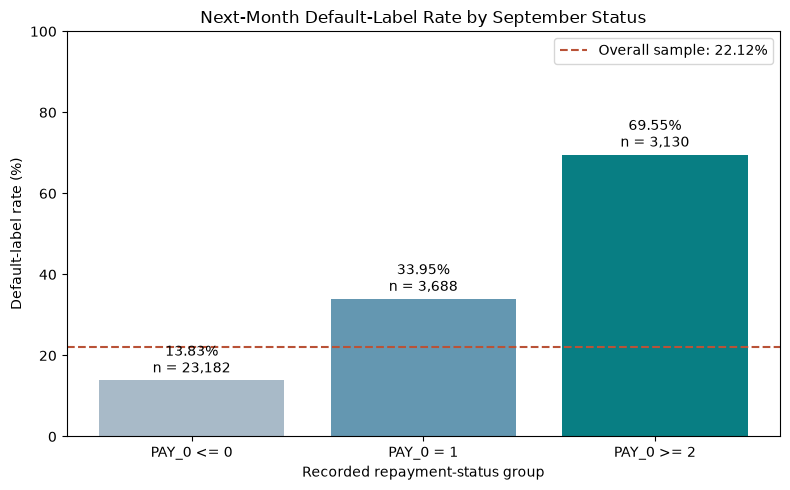

In [13]:
import matplotlib.pyplot as plt

# Keep the segments in a deliberate display order.
group_order = ["PAY_0 <= 0", "PAY_0 = 1", "PAY_0 >= 2"]
plot_data = group_summary.loc[group_order]

# Convert proportions to percentages for the chart.
rates_pct = plot_data["default_rate"] * 100
baseline_pct = df[target_col].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    group_order,
    rates_pct,
    color=["#A8BAC8", "#6497B1", "#087E83"]
)

# Add the overall sample rate as a reference line.
ax.axhline(
    baseline_pct,
    color="#B95237",
    linestyle="--",
    label=f"Overall sample: {baseline_pct:.2f}%"
)

# Show both the rate and group size above each bar.
for bar, rate, clients in zip(
    bars, rates_pct, plot_data["total_clients"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{rate:.2f}%\nn = {clients:,}",
        ha="center",
        fontsize=10
    )

ax.set_title("Next-Month Default-Label Rate by September Status")
ax.set_xlabel("Recorded repayment-status group")
ax.set_ylabel("Default-label rate (%)")
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## 4. Default-Label Rates across Credit-Limit Segments

Assess how next-month default-label rates vary across
credit-limit segments, considering both rates and group sizes.

### 4.1 Inspect the Credit-Limit Distribution

Review the range and quartiles before defining credit-limit bands.

In [14]:
# Inspect the range and quartiles of granted credit limits.
df["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

### 4.2 Define Exploratory Credit-Limit Bands

Use the observed quartiles (TWD 50,000, TWD 140,000 and
TWD 240,000) to define four credit-limit bands.

These are sample-based exploratory bands, not bank policy
thresholds. Group sizes may differ because limits can repeat.

In [15]:
from core.metrics import credit_limit_bands

# Assign the exploratory credit-limit bands (TWD 50,000 / 140,000 / 240,000 boundaries).
df["limit_band"] = credit_limit_bands(df)

# Check the number of clients in each band.
print(df["limit_band"].value_counts(sort=False, dropna=False))

limit_band
<= 50,000          7676
50,000-140,000     7614
140,000-240,000    7643
> 240,000          7067
Name: count, dtype: int64


All 30,000 clients were assigned to a credit-limit band,
with no missing band assignments. Group sizes range from
7,067 to 7,676 clients.

### 4.3 Compare Default-Label Rates

Calculate the default-label rate, client share and positive-label
coverage for each credit-limit band.

These comparisons describe associations, not the effect of
changing a client's credit limit.

In [16]:
from core.metrics import segment_summary

# 4.3 Summarise Default Rates by Credit-Limit Band
limit_summary = segment_summary(df, df["limit_band"]).rename(columns={
    "positive_labels": "default_clients",
    "label_rate": "default_rate",
    "label_share": "default_share",
}).reset_index()

limit_display = limit_summary.copy()
for col in ["default_rate", "portfolio_share", "default_share"]:
    limit_display[col] = limit_display[col].map("{:.2%}".format)

display(limit_display)

,limit_band,total_clients,default_clients,default_rate,portfolio_share,default_share
0,"<= 50,000",7676,2440,31.79%,25.59%,36.77%
1,"50,000-140,000",7614,1882,24.72%,25.38%,28.36%
2,"140,000-240,000",7643,1326,17.35%,25.48%,19.98%
3,"> 240,000",7067,988,13.98%,23.56%,14.89%


### Findings

Observed default-label rates decrease across the four
credit-limit bands, from 31.79% in the lowest band to
13.98% in the highest band.

The lowest band contains 25.59% of clients but 36.77%
of all positive labels. The two lower-limit bands have
rates above the overall sample rate of 22.12%.

These are unadjusted associations. Differences in repayment
history or prior credit assessment may contribute to the
pattern; increasing credit limits cannot be assumed to
reduce default risk.

### 4.4 Check Repayment-Status Composition

Compare the repayment-status mix across credit-limit bands
to investigate whether customer composition may help explain
the observed rate differences.

In [17]:
# Calculate the repayment-status mix within each credit-limit band.
status_by_limit = pd.crosstab(
    df["limit_band"],
    df["pay0_group"],
    normalize="index"
)

# Format a separate display copy.
display((status_by_limit * 100).round(2).astype(str) + "%")

pay0_group,PAY_0 <= 0,PAY_0 = 1,PAY_0 >= 2
limit_band,,,
"<= 50,000",67.52%,15.29%,17.18%
"50,000-140,000",74.61%,11.96%,13.42%
"140,000-240,000",81.68%,11.87%,6.45%
"> 240,000",85.96%,9.85%,4.19%


### Composition Findings

The share of clients with PAY_0 >= 2 decreases from 17.18%
in the lowest credit-limit band to 4.19% in the highest band.

Lower-limit bands therefore contain a larger proportion
of clients in a repayment-status segment associated with
higher default-label rates.

This composition difference may contribute to the overall
rate pattern. The next step is to compare credit-limit
bands within the same repayment-status group.

### 4.5 Compare Rates within Repayment-Status Groups

Compare credit-limit bands within each repayment-status
group to assess whether the rate pattern remains after
accounting for these broad status categories.

In [18]:
from core.metrics import stratified_summary

# Group by repayment status first, then by credit-limit band.
within_status = stratified_summary(
    df, [df["pay0_group"], df["limit_band"]]
).rename(columns={
    "positive_labels": "default_clients",
    "label_rate": "default_rate",
})[["total_clients", "default_clients", "default_rate"]]

# Keep counts visible when comparing subgroup rates.
within_status_display = within_status.copy()

within_status_display["default_rate"] = (
    within_status_display["default_rate"].map("{:.2%}".format)
)

display(within_status_display)

total_clients  default_clients default_rate
pay0_group limit_band                                                  
PAY_0 <= 0 <= 50,000                 5183             1033       19.93%
           50,000-140,000            5681              837       14.73%
           140,000-240,000           6243              736       11.79%
           > 240,000                 6075              601        9.89%
PAY_0 = 1  <= 50,000                 1174              496       42.25%
           50,000-140,000             911              322       35.35%
           140,000-240,000            907              252       27.78%
           > 240,000                  696              182       26.15%
PAY_0 >= 2 <= 50,000                 1319              911       69.07%
           50,000-140,000            1022              723       70.74%
           140,000-240,000            493              338       68.56%
           > 240,000                  296              205       69.26%

### Findings from Stratified Analysis

Within PAY_0 <= 0 and PAY_0 = 1, default-label rates decrease
across increasing credit-limit bands. Differences in the
three broad repayment-status groups therefore do not fully
explain the overall credit-limit pattern.

Within PAY_0 >= 2, observed rates range from 68.56% to 70.74%,
with no clear monotonic relationship across credit-limit bands.
Higher limits do not identify an obviously lower-rate subgroup
within this segment.

These are descriptive comparisons, not evidence of causation
or statistical equivalence. The broad status groups may still
contain different underlying customer characteristics.

### 4.6 Visualise the Within-Status Comparisons

Compare default-label rates across credit-limit bands
within each repayment-status group.

The chart highlights where the overall credit-limit
pattern persists and where it becomes less apparent.

In [19]:
# Reshape the existing results: rows = limit bands, columns = status groups.
rate_table = within_status["default_rate"].unstack("pay0_group")

# Keep the status groups in a consistent order.
rate_table = rate_table[
    ["PAY_0 <= 0", "PAY_0 = 1", "PAY_0 >= 2"]
]

display(rate_table)

pay0_group,PAY_0 <= 0,PAY_0 = 1,PAY_0 >= 2
limit_band,,,
"<= 50,000",0.199305,0.422487,0.690675
"50,000-140,000",0.147333,0.353458,0.707436
"140,000-240,000",0.117892,0.277839,0.685598
"> 240,000",0.098930,0.261494,0.692568


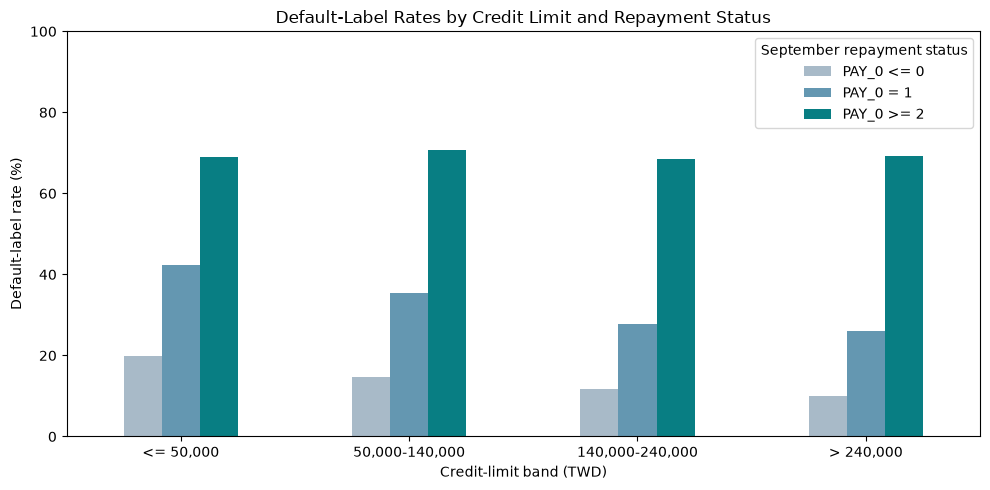

In [20]:
# Plot percentages from the numeric rate table.
ax = (rate_table * 100).plot(
    kind="bar",
    figsize=(10, 5),
    color=["#A8BAC8", "#6497B1", "#087E83"],
    rot=0
)

ax.set_title("Default-Label Rates by Credit Limit and Repayment Status")
ax.set_xlabel("Credit-limit band (TWD)")
ax.set_ylabel("Default-label rate (%)")
ax.set_ylim(0, 100)
ax.legend(title="September repayment status")

plt.tight_layout()
plt.show()

The declining rate pattern across credit-limit bands is
visible within PAY_0 <= 0 and PAY_0 = 1, but not within
PAY_0 >= 2. This is a descriptive comparison, not evidence
that increasing a client's limit would reduce risk.

## 5. Compare Candidate Review Scopes

Compare two illustrative review scopes based on September
repayment status: PAY_0 >= 2 and PAY_0 > 0.

Assess the trade-off between review workload and positive-label
coverage. These are retrospective comparisons, not validated
operational rules.

In [21]:
from core.review_scopes import (
    SCOPE_A_LABEL,
    SCOPE_B_LABEL,
    scope_a_condition,
    scope_b_condition,
    scope_metrics,
)

# Define candidate review scopes using recorded status codes.
scopes = {
    SCOPE_A_LABEL: scope_a_condition(df),
    SCOPE_B_LABEL: scope_b_condition(df),
}

review_comparison = []

for name, condition in scopes.items():
    metrics = scope_metrics(df, condition, target_col=target_col)

    review_comparison.append({
        "Review Scope": name,
        "Clients to Review": metrics["clients"],
        "Workload Share": metrics["workload_share"],
        "Positive Labels Selected": metrics["positive_labels"],
        "Positive-Label Coverage": metrics["positive_label_coverage"],
        "Observed Label Rate": metrics["label_rate"],
    })

comparison_df = pd.DataFrame(review_comparison)

# Format a separate copy for presentation.
display_df = comparison_df.copy()

for col in [
    "Workload Share",
    "Positive-Label Coverage",
    "Observed Label Rate"
]:
    display_df[col] = display_df[col].map("{:.2%}".format)

display(display_df)

,Review Scope,Clients to Review,Workload Share,Positive Labels Selected,Positive-Label Coverage,Observed Label Rate
0,Scope A: PAY_0 >= 2,3130,10.43%,2177,32.81%,69.55%
1,Scope B: PAY_0 > 0,6818,22.73%,3429,51.67%,50.29%


### 5.1 Assess the Incremental Review Population

Identify clients added when expanding Scope A to Scope B.
Measure the additional workload and positive-label coverage.

In [22]:
from core.review_scopes import incremental_metrics, scope_a_condition, scope_b_condition

# Identify clients included in B but not in A.
condition_a = scope_a_condition(df)
condition_b = scope_b_condition(df)

increment = incremental_metrics(df, condition_a, condition_b, target_col=target_col)

print(f"Additional clients to review: {increment['clients']:,}")
print(f"Additional positive labels: {increment['positive_labels']:,}")
print(f"Label rate among additional clients: {increment['label_rate']:.2%}")
print(f"Coverage gain: {increment['coverage_gain'] * 100:.2f} percentage points")

Additional clients to review: 3,688
Additional positive labels: 1,252
Label rate among additional clients: 33.95%
Coverage gain: 18.87 percentage points


### Findings: Incremental Workload and Coverage

Expanding Scope A to Scope B adds 3,688 clients to review,
an approximately 118% increase over Scope A's workload.

The additional population contains 1,252 positive labels,
increasing coverage by 18.87 percentage points. Its observed
label rate is 33.95%, compared with 69.55% in Scope A.

Scope A offers greater concentration, while Scope B offers
broader coverage at substantially higher review volume.
Neither scope can be preferred without considering review
capacity, costs and the purpose of follow-up.

These results measure historical label coverage, not losses
prevented or intervention effectiveness.

## 6. Validate the Analysis

Reconcile customer counts and positive-label totals across
the summary tables. Confirm that the two review scopes and
their incremental population are internally consistent.

In [23]:
# Check that every segmentation accounts for the full sample.
summary_tables = {
    "Repayment-status groups": group_summary,
    "Credit-limit bands": limit_summary,
    "Status and credit-limit combinations": within_status
}

for name, table in summary_tables.items():
    assert table["total_clients"].sum() == total_clients, (
        f"{name}: client count does not reconcile."
    )

    assert table["default_clients"].sum() == default_clients, (
        f"{name}: positive-label count does not reconcile."
    )

    print(f"PASS: {name}")

# Recheck the review-scope relationship and incremental population using the shared module.
from core.review_scopes import compare_scopes

scope_check = compare_scopes(df, target_col=target_col)

assert scope_check["scope_a_subset_of_scope_b"], (
    "Scope A contains clients outside Scope B."
)

assert scope_check["scope_b"]["clients"] == (
    scope_check["scope_a"]["clients"] + scope_check["increment"]["clients"]
)

assert scope_check["scope_b"]["positive_labels"] == (
    scope_check["scope_a"]["positive_labels"] + scope_check["increment"]["positive_labels"]
)

print("PASS: Review-scope counts and incremental population")

PASS: Repayment-status groups
PASS: Credit-limit bands
PASS: Status and credit-limit combinations
PASS: Review-scope counts and incremental population


### 6.1 Validation Results

Client counts and positive-label totals reconcile across
the repayment-status, credit-limit and combined segment tables.

Scope A is fully contained within Scope B. The additional
population reconciles with the difference between the scopes.

These checks confirm internal consistency, not independent
validation of the findings.

### 6.2 Limitations

- **Historical sample:** The data describes Taiwanese credit
  card clients in 2005. Results should not be presented as
  current Canadian portfolio risk.

- **Incomplete definitions:** The reviewed source description
  does not fully explain repayment codes -2 and 0 or the
  operational threshold for the default-payment label.

- **Descriptive associations:** Credit-limit comparisons do
  not establish causation. Stratification uses broad repayment
  groups and does not account for all customer differences.

- **In-sample assessment:** Review scopes were assessed on
  the same sample used for exploration. Their performance
  on new clients or later periods has not been validated.

- **Unknown intervention value:** The data does not establish
  review costs, follow-up effectiveness or losses prevented.
  Label coverage is not a measure of financial benefit.

## 7. Findings and Recommendations

### 7.1 Key Findings

**Recent repayment status identifies a concentrated segment.**
Clients with PAY_0 >= 2 represent 10.43% of the sample and
32.81% of all positive labels. Their default-label rate is
69.55%, compared with 22.12% overall. However, 67.19% of
positive labels fall outside this segment.

**The credit-limit pattern differs by repayment status.**
Default-label rates decline across increasing credit-limit
bands within PAY_0 <= 0 and PAY_0 = 1. Within PAY_0 >= 2,
rates remain between 68.56% and 70.74%, with no clear
monotonic pattern.

**Broader review increases coverage and workload.**
Expanding from PAY_0 >= 2 to PAY_0 > 0 adds 3,688 clients
and 1,252 positive labels. Coverage increases by 18.87
percentage points, while review volume increases by
approximately 118%.

### 7.2 Recommended Next Steps

1. **Clarify source definitions.**
   Confirm the repayment-status codes and outcome definition
   before translating the analysis into operational rules.

2. **Validate both review scopes on recent independent data.**
   Assess whether their concentration and coverage persist
   outside the historical sample used for exploration.

3. **Evaluate review capacity and costs.**
   Scope A offers higher concentration; Scope B offers broader
   coverage. Select a scope only after considering operational
   capacity and the intended follow-up action.

4. **Do not use higher limits alone to deprioritise clients
   with PAY_0 >= 2.**
   The observed rates are similarly high across limit bands
   within this group. This finding requires further validation.

### 7.3 Decision Requested

Agree on the intended follow-up action and available review
capacity, then prioritise validation of the candidate scopes.

No immediate change to lending policy or individual credit
limits is recommended from this historical analysis alone.